In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error

In [5]:
df = pd.read_csv("IMDb Movies India.csv",encoding='latin1')
print(df.head())




                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None


In [7]:
df = df.dropna()

In [11]:
df['Actor'] = df['Actor 1'] + "," + df['Actor 2'] + "," + df['Actor 3']
df['Actor'] = df['Actor'].apply(lambda x: x.split(',')[0])

In [12]:
le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])
df['Director'] = le.fit_transform(df['Director'])
df['Actor'] = le.fit_transform(df['Actor'])



In [13]:
X = df[['Genre', 'Director', 'Actor']]
y = df['Rating']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE:", mse)
print("R2 Score:", r2)


Model Performance:
MSE: 1.751700274512773
R2 Score: 0.05402657750570683


In [19]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted Ratings:")
print(comparison.head())


Actual vs Predicted Ratings:
   Actual  Predicted
0     6.0     5.7990
1     2.4     6.9710
2     3.8     5.6600
3     3.8     4.5566
4     7.2     6.7780


In [25]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 1.751700274512773


In [26]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 1.3235181428725384


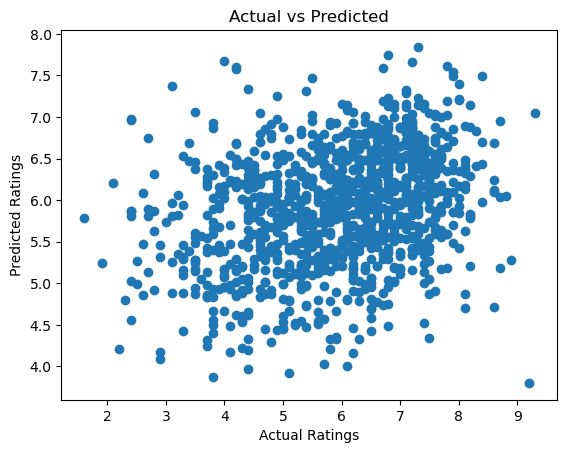

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted")
plt.show()

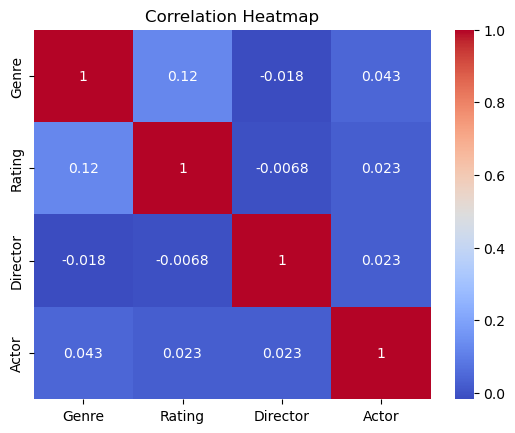

In [28]:
plt.figure()
sns.heatmap(df.select_dtypes(include=["number"]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()